# Day 2 · Notebook 2 — Titanic: from EDA to classification
### ML Bootcamp · Day 2 of 5

**Question:** can we predict which passengers survived the Titanic?

This notebook follows the full ML workflow:

1. **Explore** the data with charts (EDA)
2. **Clean** it: missing values, leaky columns
3. **Engineer** new features
4. **Encode** text columns as numbers
5. **Split & scale**
6. **Train** classifiers and **evaluate** them properly

> Run the cells in order with **Shift + Enter**. 🧠 = think about it, ✍️ = exercise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = sns.load_dataset("titanic")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Part 1 · First look

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
missing = df.isna().sum()
missing[missing > 0]

,0
age,177
embarked,2
deck,688
embark_town,2


In [4]:
print(f"Survival rate overall: {df['survived'].mean():.1%}")

Survival rate overall: 38.4%


---
## Part 2 · EDA with charts

### 2.1 How many survived? (count plot)

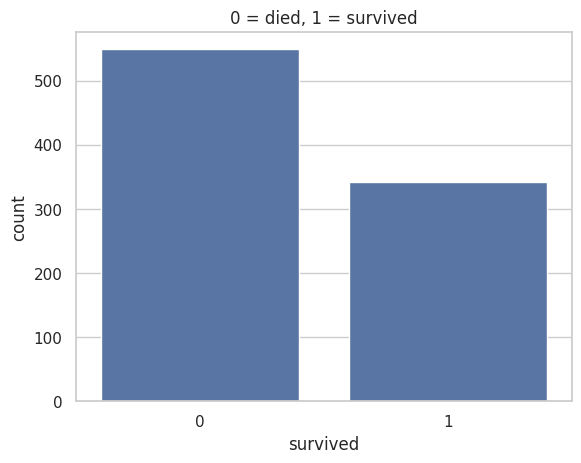

In [5]:
sns.countplot(data=df, x="survived")
plt.title("0 = died, 1 = survived")
plt.show()

### 2.2 Did sex matter? (`hue` splits each bar by a category)

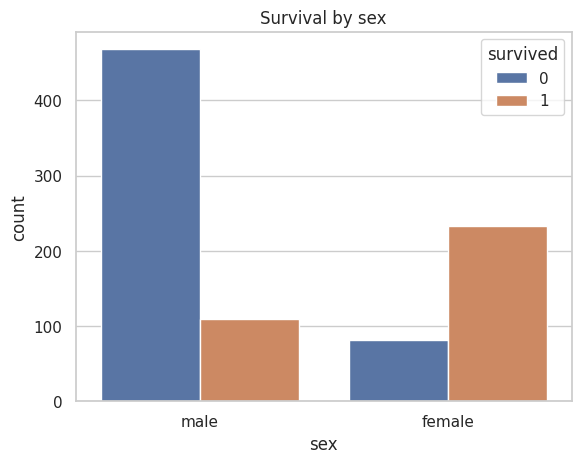

sex
female    0.742
male      0.189
Name: survived, dtype: float64


In [6]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by sex")
plt.show()

print(df.groupby("sex")["survived"].mean().round(3))

### 2.3 Did ticket class matter?
A **bar plot** of a 0/1 column shows the **average** — the survival rate — with a small error bar.

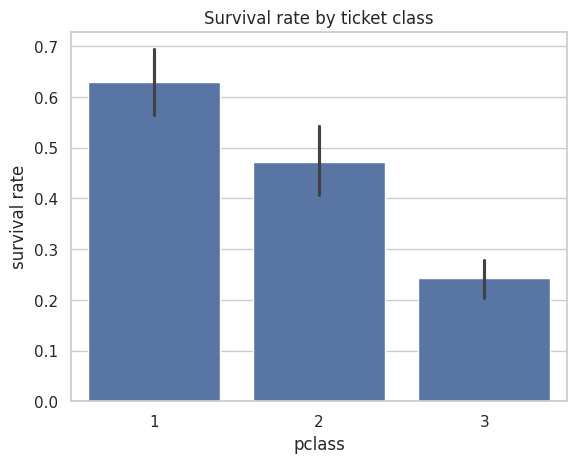

pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


In [7]:
sns.barplot(data=df, x="pclass", y="survived")
plt.title("Survival rate by ticket class")
plt.ylabel("survival rate")
plt.show()

print(df.groupby("pclass")["survived"].mean().round(3))

### 2.4 How were ages spread? (histogram)

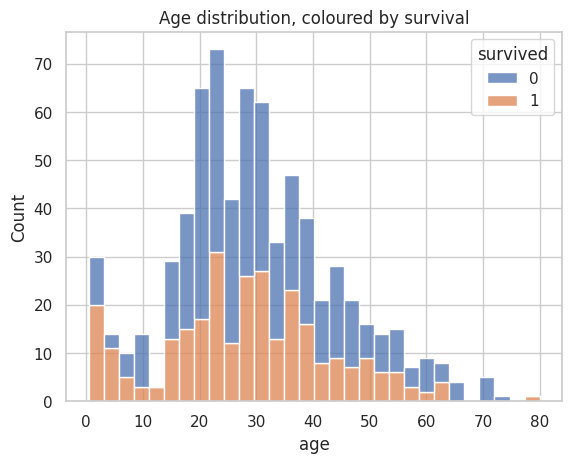

In [8]:
sns.histplot(data=df, x="age", hue="survived", bins=30, multiple="stack")
plt.title("Age distribution, coloured by survival")
plt.show()

### 2.5 Fares and outliers (box plot)
The box shows the middle 50% of fares; dots are **outliers** far from the rest.

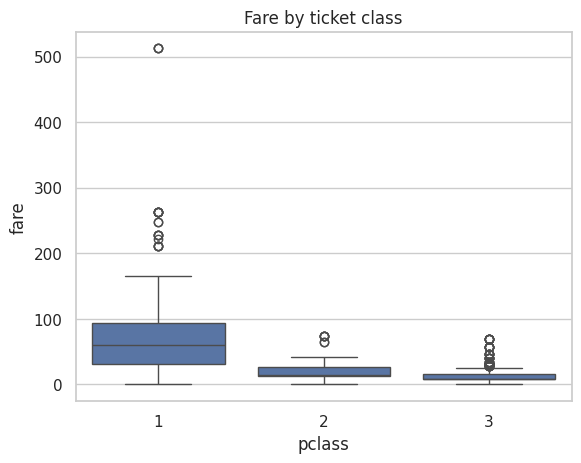

Fare mean: 32.2 | median: 14.4542 | max: 512.3292


In [9]:
sns.boxplot(data=df, x="pclass", y="fare")
plt.title("Fare by ticket class")
plt.show()

print("Fare mean:", round(df["fare"].mean(), 1), "| median:", df["fare"].median(), "| max:", df["fare"].max())

### 2.6 Which number columns are related? (heatmap)
Correlation goes from **−1** (move in opposite directions) to **+1** (move together). 0 = no straight-line relationship.

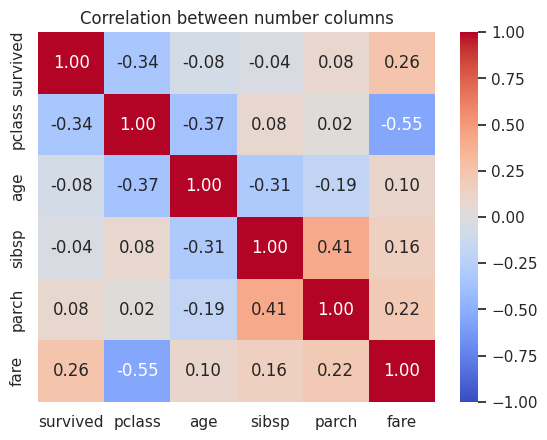

In [10]:
num_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between number columns")
plt.show()

> 🧠 **Think about it**
> - Which two groups had the best chance of surviving? The worst?
> - `pclass` and `fare` have a strong negative correlation. Why does that make sense?
> - If you could use only **one** column to guess survival, which would you pick?

---
## Part 3 · Cleaning

### 3.1 Watch out for data leakage!
The `alive` column looks useful... but check it against `survived`:

In [11]:
pd.crosstab(df["survived"], df["alive"])

alive,no,yes
survived,,
0,549,0
1,0,342


`alive` is just `survived` written as yes/no. If we left it in, the model would "cheat" and look perfect — but it's useless for real predictions. This is **data leakage**. Columns like `class`, `who`, `adult_male` and `embark_town` also just repeat other columns.

We'll keep only the columns we need:

In [12]:
data = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
data.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2


### 3.2 Fill missing values
- **age**: fill with the **median** (28), which isn't pulled around by very old or young passengers
- **embarked**: only 2 missing → fill with the **most common** port (the *mode*)
- **deck** was 77% missing, so we simply didn't keep it

*(Strictly, the median should come from the training rows only. It makes almost no difference here; we'll do it the fully correct way with Pipelines on Day 3.)*

In [13]:
print("Median age:", data["age"].median())
print("Most common port:", data["embarked"].mode()[0])

data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

data.isna().sum().sum()   # total missing values left -> should be 0

Median age: 28.0
Most common port: S


np.int64(0)

---
## Part 4 · Feature engineering
`sibsp` (siblings/spouses) and `parch` (parents/children) make more sense combined.

In [14]:
data["family_size"] = data["sibsp"] + data["parch"] + 1
data["is_alone"] = (data["family_size"] == 1).astype(int)

print(data.groupby("is_alone")["survived"].mean().round(3))

is_alone
0    0.506
1    0.304
Name: survived, dtype: float64


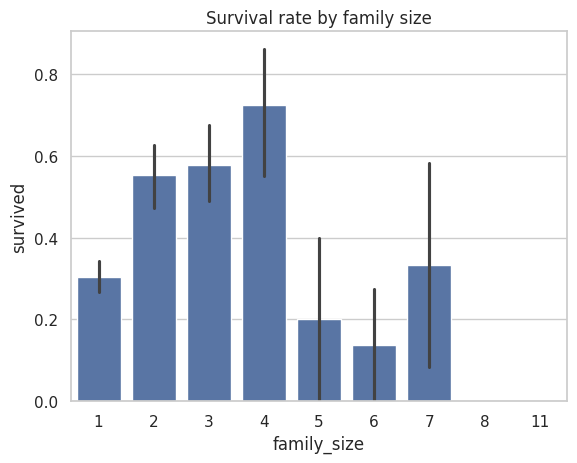

In [15]:
sns.barplot(data=data, x="family_size", y="survived")
plt.title("Survival rate by family size")
plt.show()

> 🧠 Small families (2–4) did best. Travelling alone, or in a very large family, was worse. Can you think why?

---
## Part 5 · Encoding text as numbers
- `sex` has two values → **binary** encoding: male = 0, female = 1
- `embarked` (C, Q, S) has no order → **one-hot** encoding. `drop_first=True` drops one column because it can be worked out from the others (if C = 0 and Q = 0, it must be S).

In [16]:
data["sex"] = data["sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["embarked"], drop_first=True, dtype=int)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size,is_alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,2,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,1,0,1


---
## Part 6 · Split and scale
- **X** = features (inputs), **y** = label (`survived`)
- 80% train / 20% test. `stratify=y` keeps the same share of survivors in both sets; `random_state=42` makes the split the same for everyone.
- The scaler is **fit on the training set only**, then applied to both — no peeking at the test set!

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop(columns="survived")
y = data["survived"]
print("Features:", list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'embarked_Q', 'embarked_S']
Train: (712, 10) | Test: (179, 10)


---
## Part 7 · Train and evaluate classifiers

### 7.1 A baseline first
What if we just predicted "died" for everyone? Any real model must beat this.

In [18]:
baseline_acc = (y_test == 0).mean()
print(f"Baseline (always 'died') accuracy: {baseline_acc:.1%}")

Baseline (always 'died') accuracy: 61.5%


### 7.2 Logistic regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
pred = logreg.predict(X_test_s)

print(f"Accuracy: {accuracy_score(y_test, pred):.1%}")

Accuracy: 80.4%


### 7.3 The confusion matrix
Rows = what really happened, columns = what the model predicted.

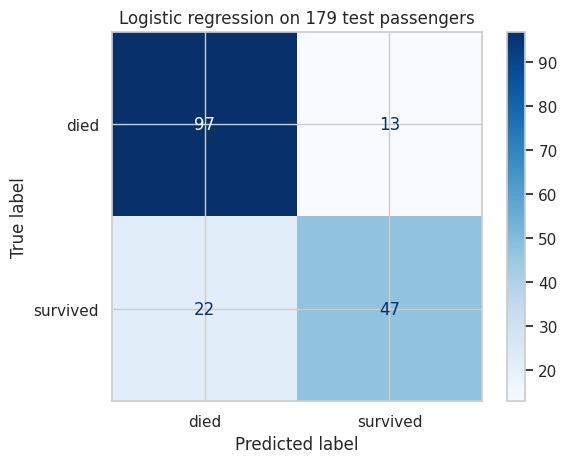

In [20]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(cmap="Blues")
plt.title("Logistic regression on 179 test passengers")
plt.show()

In [21]:
print(classification_report(y_test, pred, target_names=["died", "survived"]))

              precision    recall  f1-score   support

        died       0.82      0.88      0.85       110
    survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



- **Precision** (survived): when the model says "survived", how often is it right?
- **Recall** (survived): of the real survivors, how many did it find?
- **F1**: a balance of the two

### 7.4 What did logistic regression learn?
Positive weight → higher chance of survival. (Features were scaled, so the sizes are comparable.)

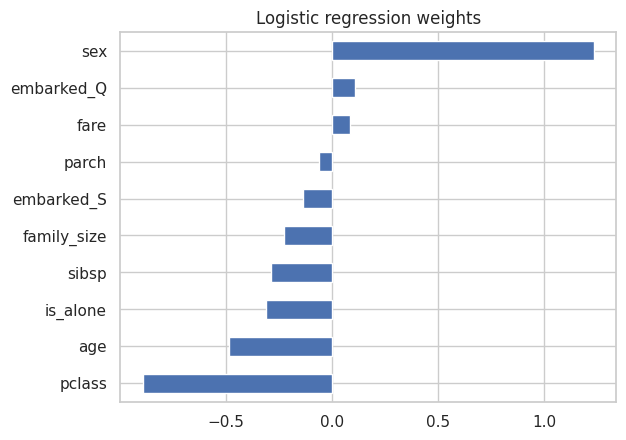

In [22]:
weights = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
weights.plot(kind="barh")
plt.title("Logistic regression weights")
plt.show()

### 7.5 Try other models — same recipe, one line changes

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision tree (depth 4)": DecisionTreeClassifier(max_depth=4, random_state=42),
}

rows = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    p = model.predict(X_test_s)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, p),
        "precision": precision_score(y_test, p),
        "recall": recall_score(y_test, p),
        "f1": f1_score(y_test, p),
    })

results = pd.DataFrame(rows).set_index("model").round(3)
results

,accuracy,precision,recall,f1
model,,,,
Logistic regression,0.804,0.783,0.681,0.729
KNN (k=5),0.816,0.790,0.710,0.748
Decision tree (depth 4),0.788,0.844,0.551,0.667


> 🧠 Which model would you choose if missing a survivor was the worst mistake? (Look at **recall**.) Which if false alarms were the worst? (Look at **precision**.)

### 7.6 Warning sign: overfitting
Compare accuracy on the **training** data with accuracy on the **test** data.

In [24]:
for depth in [None, 4]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train_s, y_train)
    label = "no limit" if depth is None else f"max depth {depth}"
    print(f"Tree ({label:12s}) train: {tree.score(X_train_s, y_train):.1%}   test: {tree.score(X_test_s, y_test):.1%}")

Tree (no limit    ) train: 98.2%   test: 79.9%
Tree (max depth 4 ) train: 83.8%   test: 78.8%


The unlimited tree scores ~98% on passengers it has seen but only ~80% on new ones: it **memorised** the training data. A big train/test gap = **overfitting**. Fixes are on Day 3.

---
## Part 8 · Predict for new passengers 🚢
Two (fictional) passengers board the ship. The new rows must have **exactly the same columns** as `X`, and must be **scaled with the same scaler**.

In [25]:
new_passengers = pd.DataFrame([
    # pclass, sex(1=female), age, sibsp, parch, fare, family_size, is_alone, embarked_Q, embarked_S
    {"pclass": 1, "sex": 1, "age": 17, "sibsp": 1, "parch": 1, "fare": 100.0,
     "family_size": 3, "is_alone": 0, "embarked_Q": 0, "embarked_S": 1},
    {"pclass": 3, "sex": 0, "age": 20, "sibsp": 0, "parch": 0, "fare": 7.9,
     "family_size": 1, "is_alone": 1, "embarked_Q": 0, "embarked_S": 1},
], index=["1st-class girl, 17", "3rd-class man, 20"])[X.columns]

probs = logreg.predict_proba(scaler.transform(new_passengers))[:, 1]
for name, p in zip(new_passengers.index, probs):
    print(f"{name}: {p:.0%} chance of survival")

1st-class girl, 17: 95% chance of survival
3rd-class man, 20: 11% chance of survival


> ✍️ **Exercises**
> 1. Try `KNeighborsClassifier` with `n_neighbors` = 1, 5, 15 and 30. Which gives the best test accuracy?
> 2. Create a new feature `fare_per_person = fare / family_size`, add it to `X`, and retrain logistic regression. Did accuracy change?
> 3. Change the decision threshold: predict "survived" only if the probability is above **0.7** (hint: `logreg.predict_proba(X_test_s)[:, 1] > 0.7`). What happens to precision and recall?

---
## 🎯 Recap
EDA → drop leaky columns → fill missing values → engineer features → encode → split → scale (fit on train!) → train → evaluate with a baseline, confusion matrix, precision and recall → watch for overfitting.

---
## ✅ Solutions

In [26]:
# Exercise 1
for k in [1, 5, 15, 30]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    print(f"k={k:2d}  train {knn.score(X_train_s, y_train):.1%}  test {knn.score(X_test_s, y_test):.1%}")
# k=1 memorises the training set (look at the train score) - another example of overfitting.

k= 1  train 98.2%  test 78.2%
k= 5  train 85.0%  test 81.6%
k=15  train 82.9%  test 83.2%
k=30  train 81.5%  test 82.1%


In [27]:
# Exercise 2
X2 = X.copy()
X2["fare_per_person"] = X2["fare"] / X2["family_size"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42, stratify=y)
sc2 = StandardScaler().fit(X2_train)
lr2 = LogisticRegression(max_iter=1000).fit(sc2.transform(X2_train), y2_train)
print(f"With fare_per_person: {lr2.score(sc2.transform(X2_test), y2_test):.1%}  (before: {accuracy_score(y_test, pred):.1%})")
# Not every new feature helps! That's normal - feature engineering is trial and error.

With fare_per_person: 80.4%  (before: 80.4%)


In [28]:
# Exercise 3
probs_test = logreg.predict_proba(X_test_s)[:, 1]
for threshold in [0.5, 0.7]:
    p = (probs_test > threshold).astype(int)
    print(f"threshold {threshold}: precision {precision_score(y_test, p):.1%}, recall {recall_score(y_test, p):.1%}")
# A higher threshold = more careful: higher precision, lower recall.

threshold 0.5: precision 78.3%, recall 68.1%
threshold 0.7: precision 88.1%, recall 53.6%
